In [8]:
%pip install scipy scikit-learn seaborn yfinance pandas numpy matplotlib

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.3 MB 15.3 MB/s eta 0:00:01
   ------------------------------------- -- 7.9/8.3 MB 21.5 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 19.6 MB/s  0:00:00

   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   ---------------- ----------------------- 2/5 [joblib]
   ---------------- ----------------------- 2/5 [joblib]
   ------------------------ --------------- 3/5 [scikit-learn]
   ------------------------ --------------- 3/5 [scikit-learn]
   ------------------------ --------------- 3/5 [scikit-learn]
   ------------------------ --------------- 3/5 [scikit-learn]
   ------------------------ --------------- 3/5 [scikit-learn]
   ------------------------ ---------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install sklearn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [2]:
%pip install scipy

   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   --- ------------------------------------ 3.7/37.3 MB 19.4 MB/s eta 0:00:02
   -------- ------------------------------- 7.6/37.3 MB 19.5 MB/s eta 0:00:02
   --------------- ------------------------ 14.2/37.3 MB 23.4 MB/s eta 0:00:01
   --------------------- ------------------ 20.4/37.3 MB 25.4 MB/s eta 0:00:01
   ---------------------------- ----------- 26.5/37.3 MB 25.9 MB/s eta 0:00:01
   ------------------------------------ --- 33.8/37.3 MB 27.3 MB/s eta 0:00:01
   ---------------------------------------- 37.3/37.3 MB 26.0 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
# Librerías necesarias — no modifique esta celda
from matplotlib import pyplot as plt
from scipy.stats import f_oneway, mannwhitneyu, kruskal, levene, bartlett
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import seaborn as sns
import yfinance as yf
import pandas as pd
import numpy as np

sns.set_style("dark")
np.random.seed(20260607)

In [17]:
# Parte 1: Transformación de datos financieros
# a) Descargue los precios de cierre del portafolio definido anteriormente.

def precios_cierre_portafolio(tickers, start, end):
    df = yf.download(tickers, start=start, end=end)['Close']
    return df

tickers = ["AAPL", "AMZN", "JPM", "GS", "TSLA"]
start = "2021-01-01"
end = "2024-12-31"

df = precios_cierre_portafolio(tickers, start, end)
print(df)

[*********************100%***********************]  5 of 5 completed

Ticker            AAPL        AMZN          GS         JPM        TSLA
2021-01-04  125.740860  159.331497  233.060898  109.491554  243.256668
2021-01-05  127.295471  160.925507  238.276184  110.087349  245.036667
2021-01-06  123.010536  156.919006  251.134140  115.256569  251.993332
2021-01-07  127.208015  158.108002  256.498871  119.041512  272.013336
2021-01-08  128.305984  159.134995  255.118195  119.172943  293.339996
...                ...         ...         ...         ...         ...
2024-12-23  253.649429  225.059998  553.994446  231.216537  430.600006
2024-12-24  256.560852  229.050003  565.651184  235.018585  462.279999
2024-12-26  257.375549  227.050003  564.137024  235.823624  454.130005
2024-12-27  253.967392  223.750000  559.235657  233.912903  431.660004
2024-12-30  250.598907  221.300003  556.682983  232.118576  417.410004

[1004 rows x 5 columns]


In [ ]:
# b) Retornos simples y logarítmicos

retornos_simples = df.pct_change().dropna()

retornos_simples.head()*100



Ticker,AAPL,AMZN,GS,JPM,TSLA
2021-01-05,1.236361,1.000436,2.237735,0.544147,0.731737
2021-01-06,-3.366133,-2.489661,5.396240,4.695562,2.839030
2021-01-07,3.412292,0.757713,2.136201,3.283928,7.944656
2021-01-08,0.863129,0.649551,-0.538278,0.110408,7.840299
2021-01-11,-2.324865,-2.151946,1.292724,1.492417,-7.821412


In [35]:
retornos_log = np.log(df / df.shift(1)).dropna()

print(retornos_log.head())

Ticker          AAPL      AMZN        GS       JPM      TSLA
2021-01-05  0.012288  0.009955  0.022131  0.005427  0.007291
2021-01-06 -0.034241 -0.025212  0.052557  0.045887  0.027995
2021-01-07  0.033554  0.007549  0.021137  0.032312  0.076448
2021-01-08  0.008594  0.006475 -0.005397  0.001103  0.075481
2021-01-11 -0.023523 -0.021754  0.012844  0.014814 -0.081442


In [37]:
retornos_log_TSLA = np.log(df["TSLA"] / df["TSLA"].shift(1)).dropna()
print(retornos_log_TSLA)

2021-01-05    0.007291
2021-01-06    0.027995
2021-01-07    0.076448
2021-01-08    0.075481
2021-01-11   -0.081442
                ...   
2024-12-23    0.022404
2024-12-24    0.070991
2024-12-26   -0.017787
2024-12-27   -0.050745
2024-12-30   -0.033569
Name: TSLA, Length: 1003, dtype: float64


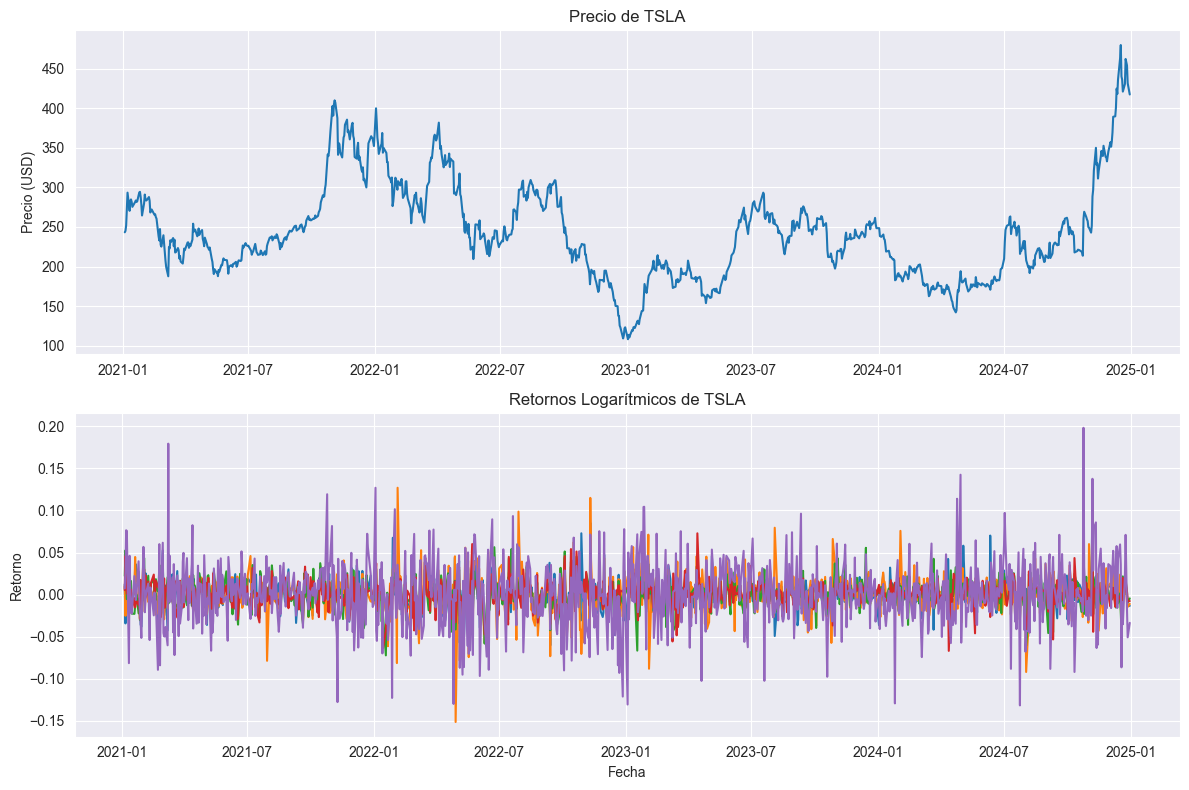

In [ ]:
# c) Para el activo TSLA, grafique en un mismo panel de dos subplots: la serie de precios y la serie de retornos logarítmicos.
# Crear figura con 2 subplots
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# Subplot 1: Serie de precios
ax[0].plot(df.index, df["TSLA"])
ax[0].set_title("Precio de TSLA")
ax[0].set_ylabel("Precio (USD)")
ax[0].grid(True)

# Subplot 2: Retornos logarítmicos
ax[1].plot(retornos_log.index, retornos_log)
ax[1].set_title("Retornos Logarítmicos de TSLA")
ax[1].set_ylabel("Retorno")
ax[1].set_xlabel("Fecha")
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# d) ¿Qué diferencias observa entre los retornos simples y logarítmicos? ¿En qué escenarios es más conveniente usar retornos logarítmicos? Justifique su respuesta.
# El retorno logarítmico es para modelamiento financiero y el retorno simple es para descripción. El retorno logarítmico es acumulativo, considerando correctamente la suma en el tiempo. Es mayormente conveniente utilizar retornos logarítmicos para modelamiento financiero.

In [48]:
# Pregunta 1.2 — Retornos Multi-Período (9 puntos)
# Para el activo JPM:
# a) Calcule los retornos diarios, semanales y mensuales (simples y logarítmicos).
# Precio cierre JPM

p_cierre_JPM = yf.download('JPM', start='2021-01-01', end='2024-12-31', progress = False)['Close']

# Retorno diario simple / logarítimico
dayli_simple_return = p_cierre_JPM.pct_change().dropna()
print(dayli_simple_return)

Ticker           JPM
2021-01-05  0.005441
2021-01-06  0.046956
2021-01-07  0.032839
2021-01-08  0.001104
2021-01-11  0.014924
...              ...
2024-12-23  0.003325
2024-12-24  0.016444
2024-12-26  0.003425
2024-12-27 -0.008102
2024-12-30 -0.007671

[1003 rows x 1 columns]


In [51]:
dayli_log_return = np.log(p_cierre_JPM / p_cierre_JPM.shift(1)).dropna()
print(dayli_log_return)

Ticker           JPM
2021-01-05  0.005427
2021-01-06  0.045887
2021-01-07  0.032312
2021-01-08  0.001103
2021-01-11  0.014814
...              ...
2024-12-23  0.003319
2024-12-24  0.016310
2024-12-26  0.003420
2024-12-27 -0.008135
2024-12-30 -0.007700

[1003 rows x 1 columns]


In [60]:
# Retornos semanales
weekly_prices = p_cierre_JPM.resample('W').last()
weekly_simple_return = weekly_prices.pct_change().dropna()
weekly_log_return = np.log(weekly_prices / weekly_prices.shift(1)).dropna()

print(weekly_log_return)
print(weekly_simple_return)


Ticker           JPM
2021-01-17  0.019079
2021-01-24 -0.035609
2021-01-31 -0.039020
2021-02-07  0.069858
2021-02-14  0.023423
...              ...
2024-12-08 -0.009496
2024-12-15 -0.030456
2024-12-22 -0.009800
2024-12-29  0.014913
2025-01-05 -0.007700

[208 rows x 1 columns]
Ticker           JPM
2021-01-17  0.019262
2021-01-24 -0.034983
2021-01-31 -0.038269
2021-02-07  0.072356
2021-02-14  0.023699
...              ...
2024-12-08 -0.009451
2024-12-15 -0.029997
2024-12-22 -0.009752
2024-12-29  0.015025
2025-01-05 -0.007671

[208 rows x 1 columns]


In [68]:
# Retornos mensuales
monthly_prices = p_cierre_JPM.resample('ME').last()
monthly_simple_return = monthly_prices.pct_change()
monthly_log_return = np.log(monthly_prices / monthly_prices.shift(1))

print(monthly_simple_return)
print(monthly_log_return)

Ticker           JPM
2021-01-31       NaN
2021-02-28  0.143779
2021-03-31  0.034382
2021-04-30  0.016330
2021-05-31  0.067811
2021-06-30 -0.052971
2021-07-31 -0.018550
2021-08-31  0.053827
2021-09-30  0.023382
2021-10-31  0.044130
2021-11-30 -0.065101
2021-12-31 -0.003022
2022-01-31 -0.055948
2022-02-28 -0.045760
2022-03-31 -0.038646
2022-04-30 -0.117923
2022-05-31  0.107825
2022-06-30 -0.148378
2022-07-31  0.033482
2022-08-31 -0.014130
2022-09-30 -0.081157
2022-10-31  0.215371
2022-11-30  0.097712
2022-12-31 -0.029527
2023-01-31  0.051408
2023-02-28  0.024221
2023-03-31 -0.090966
2023-04-30  0.069180
2023-05-31 -0.018301
2023-06-30  0.071697
2023-07-31  0.093542
2023-08-31 -0.073626
2023-09-30 -0.008952
2023-10-31 -0.034023
2023-11-30  0.122393
2023-12-31  0.089826
2024-01-31  0.031365
2024-02-29  0.067102
2024-03-31  0.076534
2024-04-30 -0.037152
2024-05-31  0.056796
2024-06-30 -0.001826
2024-07-31  0.057941
2024-08-31  0.056391
2024-09-30 -0.062011
2024-10-31  0.058901
2024-11-30  0

In [71]:
# b) Calcule el retorno acumulado a rolling 20 días usando retornos logarítmicos (recuerde la propiedad de aditividad)

rollinng_20d_log_return = np.log(p_cierre_JPM / p_cierre_JPM.shift(5)).dropna()
print(rollinng_20d_log_return)

Ticker           JPM
2021-01-11  0.099542
2021-01-12  0.109712
2021-01-13  0.064752
2021-01-14  0.038266
2021-01-15  0.019079
...              ...
2024-12-23 -0.004979
2024-12-24  0.016436
2024-12-26  0.053951
2024-12-27  0.034635
2024-12-30  0.007213

[999 rows x 1 columns]


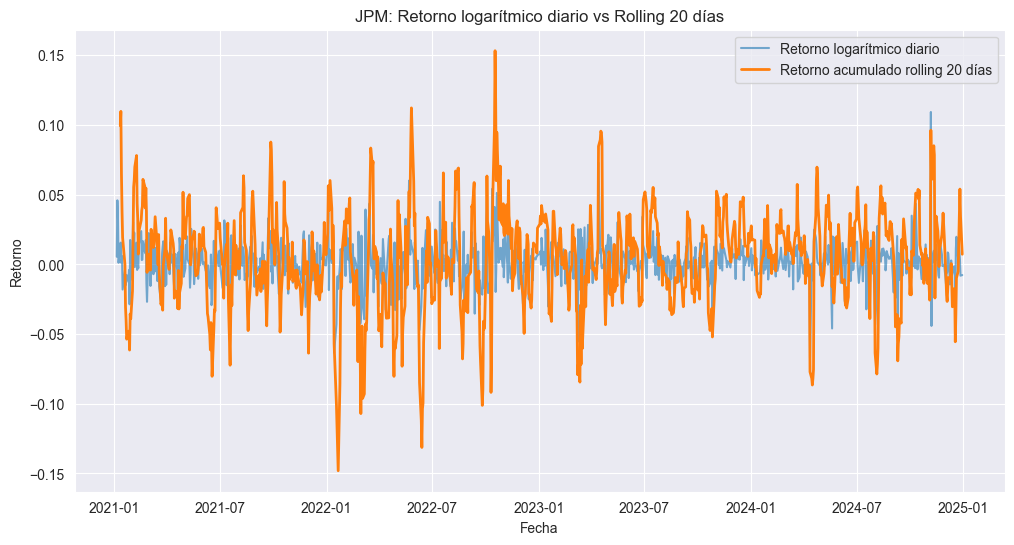

In [73]:
# c) Visualice en un solo gráfico el retorno logarítimico diario y el retorno rolling de 20 días para JPM.


plt.figure(figsize=(12,6))

plt.plot(dayli_log_return.index, dayli_log_return,
         label='Retorno logarítmico diario',
         alpha=0.6)

plt.plot(rollinng_20d_log_return.index, rollinng_20d_log_return,
         label='Retorno acumulado rolling 20 días',
         linewidth=2)

plt.title('JPM: Retorno logarítmico diario vs Rolling 20 días')
plt.xlabel('Fecha')
plt.ylabel('Retorno')
plt.legend()
plt.grid(True)

plt.show()

In [80]:
# d) Calcule la media, desviación estándar, asimetría (skewness) y curtosis para los retornos diarios de cada frecuencia (diario, semanal, mensual). Presente los resultados en un DataFrame resumen.

resumen = pd.DataFrame({
    "Media": [
        dayli_log_return["JPM"].mean(),
        weekly_log_return["JPM"].mean(),
        monthly_log_return["JPM"].mean()
    ],
    "Desv. Estándar": [
        dayli_log_return["JPM"].std(),
        weekly_log_return["JPM"].std(),
        monthly_log_return  ["JPM"].std()
    ],
    "Asimetría": [
        dayli_log_return["JPM"].skew(),
        weekly_log_return["JPM"].skew(),
        monthly_log_return["JPM"].skew()
    ],
    "Curtosis": [
        dayli_log_return["JPM"].kurtosis(),
        weekly_log_return["JPM"].kurtosis(),
        monthly_log_return["JPM"].kurtosis()
    ]
},
index=["Diario", "Semanal", "Mensual"])

print(resumen.round(4))

          Media  Desv. Estándar  Asimetría  Curtosis
Diario   0.0007          0.0152     0.1866    4.4023
Semanal  0.0032          0.0338    -0.2277    0.6628
Mensual  0.0154          0.0727    -0.0988   -0.0712
